In [1]:
!pip install pandas numpy scikit-learn matplotlib seaborn joblib ucimlrepo

In [3]:
import pandas as pd
import numpy as np
import sklearn
import matplotlib
import seaborn
import joblib

print("All libraries imported successfully")

All libraries imported successfully


In [5]:
from ucimlrepo import fetch_ucirepo

# Fetch dataset from UCI
breast_cancer = fetch_ucirepo(id=17)

X = breast_cancer.data.features
y = breast_cancer.data.targets

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (569, 30)
Target shape: (569, 1)


In [7]:
X.head()

,radius1,texture1,perimeter1,area1,smoothness1,compactness1,concavity1,concave_points1,symmetry1,fractal_dimension1,...,radius3,texture3,perimeter3,area3,smoothness3,compactness3,concavity3,concave_points3,symmetry3,fractal_dimension3
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [9]:
X.head()

,radius1,texture1,perimeter1,area1,smoothness1,compactness1,concavity1,concave_points1,symmetry1,fractal_dimension1,...,radius3,texture3,perimeter3,area3,smoothness3,compactness3,concavity3,concave_points3,symmetry3,fractal_dimension3
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [11]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 30 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   radius1             569 non-null    float64
 1   texture1            569 non-null    float64
 2   perimeter1          569 non-null    float64
 3   area1               569 non-null    float64
 4   smoothness1         569 non-null    float64
 5   compactness1        569 non-null    float64
 6   concavity1          569 non-null    float64
 7   concave_points1     569 non-null    float64
 8   symmetry1           569 non-null    float64
 9   fractal_dimension1  569 non-null    float64
 10  radius2             569 non-null    float64
 11  texture2            569 non-null    float64
 12  perimeter2          569 non-null    float64
 13  area2               569 non-null    float64
 14  smoothness2         569 non-null    float64
 15  compactness2        569 non-null    float64
 16  concavit

In [13]:
X.describe()

,radius1,texture1,perimeter1,area1,smoothness1,compactness1,concavity1,concave_points1,symmetry1,fractal_dimension1,...,radius3,texture3,perimeter3,area3,smoothness3,compactness3,concavity3,concave_points3,symmetry3,fractal_dimension3
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


In [15]:
X.isnull().sum()

radius1               0
texture1              0
perimeter1            0
area1                 0
smoothness1           0
compactness1          0
concavity1            0
concave_points1       0
symmetry1             0
fractal_dimension1    0
radius2               0
texture2              0
perimeter2            0
area2                 0
smoothness2           0
compactness2          0
concavity2            0
concave_points2       0
symmetry2             0
fractal_dimension2    0
radius3               0
texture3              0
perimeter3            0
area3                 0
smoothness3           0
compactness3          0
concavity3            0
concave_points3       0
symmetry3             0
fractal_dimension3    0
dtype: int64

In [17]:
y.value_counts()

Diagnosis
B            357
M            212
Name: count, dtype: int64

In [19]:
print(X.columns.tolist())

['radius1', 'texture1', 'perimeter1', 'area1', 'smoothness1', 'compactness1', 'concavity1', 'concave_points1', 'symmetry1', 'fractal_dimension1', 'radius2', 'texture2', 'perimeter2', 'area2', 'smoothness2', 'compactness2', 'concavity2', 'concave_points2', 'symmetry2', 'fractal_dimension2', 'radius3', 'texture3', 'perimeter3', 'area3', 'smoothness3', 'compactness3', 'concavity3', 'concave_points3', 'symmetry3', 'fractal_dimension3']


In [21]:
X.columns

Index(['radius1', 'texture1', 'perimeter1', 'area1', 'smoothness1',
       'compactness1', 'concavity1', 'concave_points1', 'symmetry1',
       'fractal_dimension1', 'radius2', 'texture2', 'perimeter2', 'area2',
       'smoothness2', 'compactness2', 'concavity2', 'concave_points2',
       'symmetry2', 'fractal_dimension2', 'radius3', 'texture3', 'perimeter3',
       'area3', 'smoothness3', 'compactness3', 'concavity3', 'concave_points3',
       'symmetry3', 'fractal_dimension3'],
      dtype='object')

In [23]:
print("Number of features:", X.shape[1])

Number of features: 30


In [25]:
y = y.iloc[:, 0]

y = y.map({
    "B": 0,
    "M": 1
})

print(y.value_counts())

Diagnosis
0    357
1    212
Name: count, dtype: int64


In [27]:
y.head()

0    1
1    1
2    1
3    1
4    1
Name: Diagnosis, dtype: int64

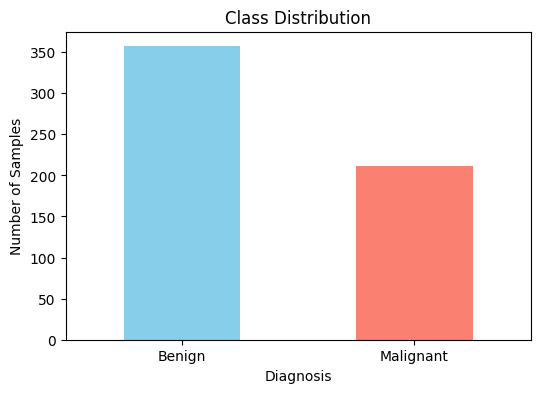

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))

y.value_counts().sort_index().plot(
    kind="bar",
    color=["skyblue", "salmon"]
)

plt.title("Class Distribution")
plt.xlabel("Diagnosis")
plt.ylabel("Number of Samples")
plt.xticks(
    [0, 1],
    ["Benign", "Malignant"],
    rotation=0
)

plt.show()

In [31]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 455
Testing samples: 114


In [35]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

In [37]:
models = {

    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("classifier", LogisticRegression(max_iter=5000))
    ]),

    "Decision Tree": DecisionTreeClassifier(
        random_state=42
    ),

    "kNN": Pipeline([
        ("scaler", StandardScaler()),
        ("classifier", KNeighborsClassifier(n_neighbors=5))
    ]),

    "Naive Bayes": GaussianNB(),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42
    )
}

print("Models created:")
for name in models:
    print("-", name)

Models created:
- Logistic Regression
- Decision Tree
- kNN
- Naive Bayes
- Random Forest


In [39]:
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef
)

In [41]:
results = []

trained_models = {}

for model_name, model in models.items():

    print("Training:", model_name)

    # Train model
    model.fit(X_train, y_train)

    # Predictions
    y_pred = model.predict(X_test)

    # Probability/decision score for AUC
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)[:, 1]
    else:
        y_score = model.decision_function(X_test)

    # Metrics
    accuracy = accuracy_score(y_test, y_pred)

    auc = roc_auc_score(
        y_test,
        y_score
    )

    precision = precision_score(
        y_test,
        y_pred,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred,
        zero_division=0
    )

    mcc = matthews_corrcoef(
        y_test,
        y_pred
    )

    # Store results
    results.append({
        "ML Model Name": model_name,
        "Accuracy": accuracy,
        "AUC": auc,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "MCC": mcc
    })

    # Store trained model
    trained_models[model_name] = model

print("All models trained successfully.")

Training: Logistic Regression
Training: Decision Tree
Training: kNN
Training: Naive Bayes
Training: Random Forest
All models trained successfully.


In [43]:
results_df = pd.DataFrame(results)

results_df

,ML Model Name,Accuracy,AUC,Precision,Recall,F1,MCC
0,Logistic Regression,0.964912,0.996032,0.975000,0.928571,0.951220,0.924518
1,Decision Tree,0.929825,0.924603,0.904762,0.904762,0.904762,0.849206
2,kNN,0.956140,0.982308,0.974359,0.904762,0.938272,0.905824
3,Naive Bayes,0.938596,0.993386,1.000000,0.833333,0.909091,0.871489
4,Random Forest,0.964912,0.994213,1.000000,0.904762,0.950000,0.925820


In [45]:
results_df.round(4)

,ML Model Name,Accuracy,AUC,Precision,Recall,F1,MCC
0,Logistic Regression,0.9649,0.9960,0.9750,0.9286,0.9512,0.9245
1,Decision Tree,0.9298,0.9246,0.9048,0.9048,0.9048,0.8492
2,kNN,0.9561,0.9823,0.9744,0.9048,0.9383,0.9058
3,Naive Bayes,0.9386,0.9934,1.0000,0.8333,0.9091,0.8715
4,Random Forest,0.9649,0.9942,1.0000,0.9048,0.9500,0.9258


In [47]:
results_df.to_csv(
    "results.csv",
    index=False
)

print("results.csv created successfully")

results.csv created successfully


In [49]:
metric_columns = [
    "Accuracy",
    "AUC",
    "Precision",
    "Recall",
    "F1",
    "MCC"
]

results_df["Average Score"] = results_df[
    metric_columns
].mean(axis=1)

results_df.sort_values(
    "Average Score",
    ascending=False
).round(4)

,ML Model Name,Accuracy,AUC,Precision,Recall,F1,MCC,Average Score
0,Logistic Regression,0.9649,0.9960,0.9750,0.9286,0.9512,0.9245,0.9567
4,Random Forest,0.9649,0.9942,1.0000,0.9048,0.9500,0.9258,0.9566
2,kNN,0.9561,0.9823,0.9744,0.9048,0.9383,0.9058,0.9436
3,Naive Bayes,0.9386,0.9934,1.0000,0.8333,0.9091,0.8715,0.9243
1,Decision Tree,0.9298,0.9246,0.9048,0.9048,0.9048,0.8492,0.9030


In [51]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

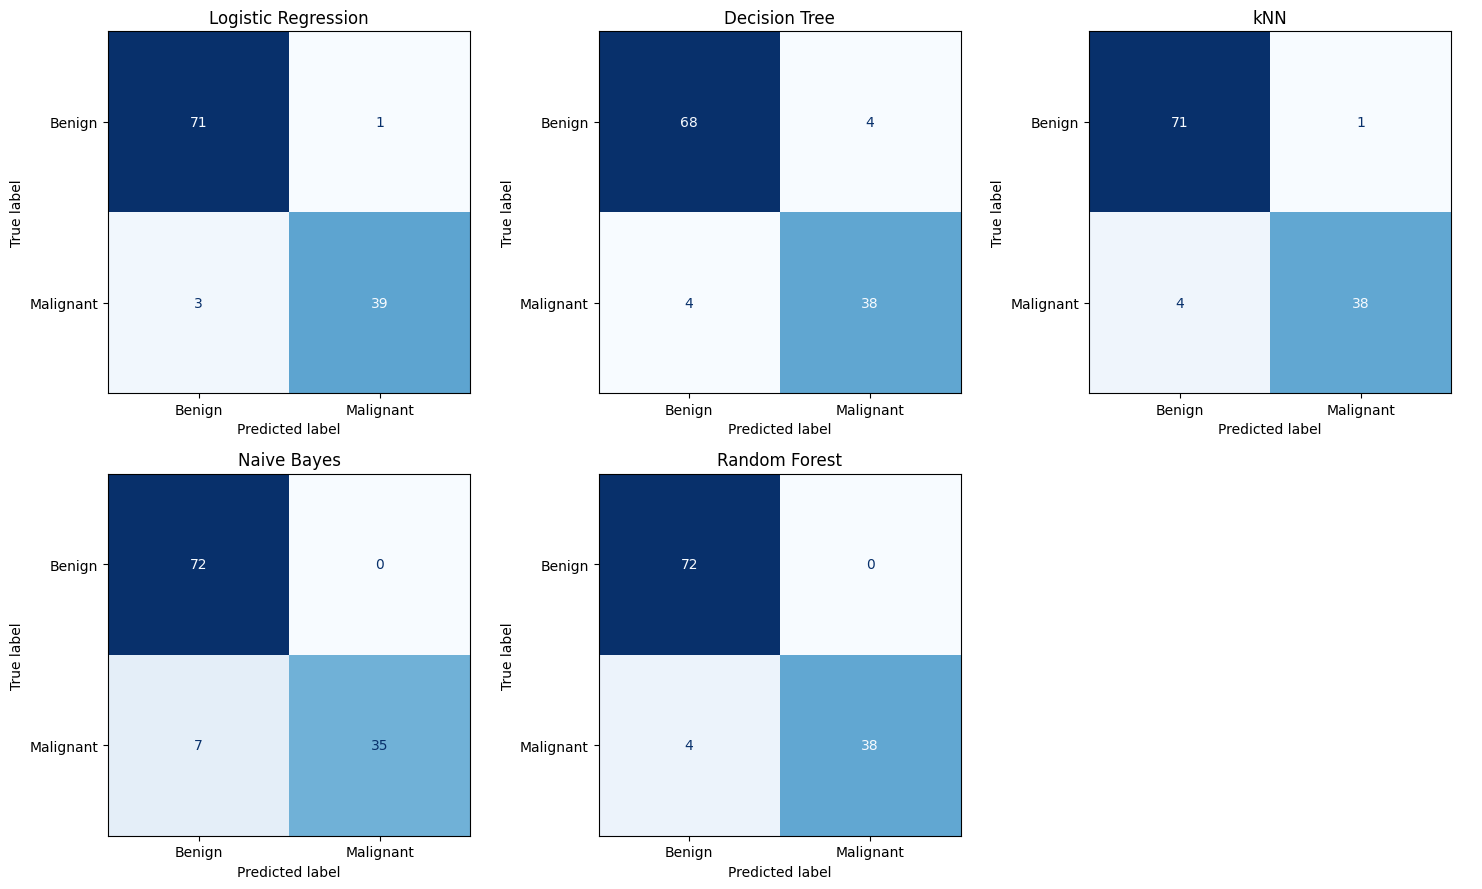

In [53]:
fig, axes = plt.subplots(
    2, 3,
    figsize=(15, 9)
)

axes = axes.flatten()

for i, (model_name, model) in enumerate(
    trained_models.items()
):

    y_pred = model.predict(X_test)

    cm = confusion_matrix(
        y_test,
        y_pred
    )

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Benign", "Malignant"]
    )

    disp.plot(
        ax=axes[i],
        cmap="Blues",
        colorbar=False
    )

    axes[i].set_title(model_name)

# Hide unused sixth subplot
axes[-1].axis("off")

plt.tight_layout()
plt.show()

In [55]:
from sklearn.metrics import classification_report

for model_name, model in trained_models.items():

    y_pred = model.predict(X_test)

    print("\n")
    print("=" * 60)
    print(model_name)
    print("=" * 60)

    print(
        classification_report(
            y_test,
            y_pred,
            target_names=[
                "Benign",
                "Malignant"
            ]
        )
    )



Logistic Regression
              precision    recall  f1-score   support

      Benign       0.96      0.99      0.97        72
   Malignant       0.97      0.93      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



Decision Tree
              precision    recall  f1-score   support

      Benign       0.94      0.94      0.94        72
   Malignant       0.90      0.90      0.90        42

    accuracy                           0.93       114
   macro avg       0.92      0.92      0.92       114
weighted avg       0.93      0.93      0.93       114



kNN
              precision    recall  f1-score   support

      Benign       0.95      0.99      0.97        72
   Malignant       0.97      0.90      0.94        42

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0

In [57]:
test_data = X_test.copy()

test_data["Diagnosis"] = y_test.values

test_data.to_csv(
    "test_data.csv",
    index=False
)

print(
    "test_data.csv created:",
    test_data.shape
)

test_data.csv created: (114, 31)


In [59]:
pd.read_csv("test_data.csv").head()

,radius1,texture1,perimeter1,area1,smoothness1,compactness1,concavity1,concave_points1,symmetry1,fractal_dimension1,...,texture3,perimeter3,area3,smoothness3,compactness3,concavity3,concave_points3,symmetry3,fractal_dimension3,Diagnosis
0,11.41,10.82,73.34,403.3,0.09373,0.06685,0.03512,0.02623,0.1667,0.06113,...,15.97,83.74,510.5,0.1548,0.2390,0.21020,0.08958,0.3016,0.08523,0
1,20.94,23.56,138.90,1364.0,0.10070,0.16060,0.27120,0.13100,0.2205,0.05898,...,27.00,165.30,2010.0,0.1211,0.3172,0.69910,0.21050,0.3126,0.07849,1
2,16.17,16.07,106.30,788.5,0.09880,0.14380,0.06651,0.05397,0.1990,0.06572,...,19.14,113.10,861.5,0.1235,0.2550,0.21140,0.12510,0.3153,0.08960,0
3,14.42,19.77,94.48,642.5,0.09752,0.11410,0.09388,0.05839,0.1879,0.06390,...,30.86,109.50,826.4,0.1431,0.3026,0.31940,0.15650,0.2718,0.09353,1
4,13.38,30.72,86.34,557.2,0.09245,0.07426,0.02819,0.03264,0.1375,0.06016,...,41.61,96.69,705.6,0.1172,0.1421,0.07003,0.07763,0.2196,0.07675,0


In [61]:
import os
import joblib

os.makedirs(
    "model",
    exist_ok=True
)

In [63]:
model_file_names = {

    "Logistic Regression":
        "logistic_regression.joblib",

    "Decision Tree":
        "decision_tree.joblib",

    "kNN":
        "knn.joblib",

    "Naive Bayes":
        "naive_bayes.joblib",

    "Random Forest":
        "random_forest.joblib"
}

In [65]:
for model_name, model in trained_models.items():

    filename = model_file_names[
        model_name
    ]

    filepath = os.path.join(
        "model",
        filename
    )

    joblib.dump(
        model,
        filepath
    )

    print("Saved:", filepath)

Saved: model/logistic_regression.joblib
Saved: model/decision_tree.joblib
Saved: model/knn.joblib
Saved: model/naive_bayes.joblib
Saved: model/random_forest.joblib
